# Deep Learning Project: CIFAR-10 Classification
## Progressive CNN Architectures with PyTorch

This notebook walks through five tasks that incrementally build more capable convolutional neural networks for image classification on the CIFAR-10 dataset.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Detect hardware
compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute device: {compute_device}")

# All 10 CIFAR-10 category names
ALL_CATEGORIES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

Compute device: cuda


## Loading CIFAR-10

We download the dataset and convert images to float tensors in the range [0, 1]. Unlike some approaches that normalize to [-1, 1], we keep the raw [0, 1] range as specified in the project requirements (floats between 0 and 1).

In [2]:
# Simple transform: just convert to tensor (automatically scales to [0,1])
data_transform = transforms.Compose([transforms.ToTensor()])

# Fetch training and test splits
training_data = torchvision.datasets.CIFAR10(
    root='./cifar10_files', train=True, download=True, transform=data_transform
)
testing_data = torchvision.datasets.CIFAR10(
    root='./cifar10_files', train=False, download=True, transform=data_transform
)

print(f"Training images: {len(training_data)}")
print(f"Testing images:  {len(testing_data)}")

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


Training images: 50000
Testing images:  10000


## Utility: Class-Filtered Dataset

A custom `Dataset` that selects only certain classes and re-indexes their labels starting from 0.

In [3]:
class FilteredCIFAR(Dataset):
    """Extracts specific classes from CIFAR-10 and assigns sequential labels."""

    def __init__(self, full_dataset, keep_classes):
        self.data_points = []
        label_lookup = {orig: seq for seq, orig in enumerate(keep_classes)}

        for idx in range(len(full_dataset)):
            img, lbl = full_dataset[idx]
            if lbl in label_lookup:
                self.data_points.append((img, label_lookup[lbl]))

    def __len__(self):
        return len(self.data_points)

    def __getitem__(self, index):
        return self.data_points[index]

## Training and Evaluation Engine

Reusable functions for training loops, accuracy measurement, prediction collection, and visualization.

In [4]:
def train_for_epochs(network, data_loader, n_epochs=10, learning_rate=0.001):
    """
    Trains a network using Adam + CrossEntropyLoss.
    Returns a list of average loss values, one per epoch.
    """
    network.to(compute_device)
    network.train()
    cost_function = nn.CrossEntropyLoss()
    adam = optim.Adam(network.parameters(), lr=learning_rate)

    loss_per_epoch = []

    for ep in range(1, n_epochs + 1):
        cumulative_loss = 0.0
        step_count = 0

        for batch_imgs, batch_labels in data_loader:
            batch_imgs = batch_imgs.to(compute_device)
            batch_labels = batch_labels.to(compute_device)

            adam.zero_grad()
            logits = network(batch_imgs)
            batch_loss = cost_function(logits, batch_labels)
            batch_loss.backward()
            adam.step()

            cumulative_loss += batch_loss.item()
            step_count += 1

        epoch_avg = cumulative_loss / step_count
        loss_per_epoch.append(epoch_avg)
        print(f"    Epoch {ep:>2d}/{n_epochs}  |  Loss = {epoch_avg:.4f}")

    return loss_per_epoch


def measure_accuracy(network, data_loader):
    """Computes classification accuracy (%) on a dataset."""
    network.eval()
    n_correct = 0
    n_total = 0

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs = imgs.to(compute_device)
            labels = labels.to(compute_device)
            logits = network(imgs)
            choices = logits.argmax(dim=1)
            n_correct += (choices == labels).sum().item()
            n_total += labels.size(0)

    return round(100.0 * n_correct / n_total, 2)


def collect_predictions(network, data_loader):
    """Returns (ground_truth, predictions) as numpy arrays."""
    network.eval()
    gt_list, pred_list = [], []

    with torch.no_grad():
        for imgs, labels in data_loader:
            logits = network(imgs.to(compute_device))
            pred_list.append(logits.argmax(dim=1).cpu().numpy())
            gt_list.append(labels.numpy())

    return np.concatenate(gt_list), np.concatenate(pred_list)

In [5]:
def draw_loss_graph(loss_values, chart_title):
    """Plots training loss across epochs."""
    epochs_range = list(range(1, len(loss_values) + 1))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(epochs_range, loss_values, 's-', color='#D35400', linewidth=2, markersize=6)
    ax.fill_between(epochs_range, loss_values, alpha=0.15, color='#D35400')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.set_title(chart_title)
    ax.set_xticks(epochs_range)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


def draw_confusion(ground_truth, predictions, label_names, chart_title):
    """Displays a confusion matrix heatmap."""
    cm = confusion_matrix(ground_truth, predictions)
    fig, ax = plt.subplots(figsize=(max(6, len(label_names) * 0.85),
                                    max(5, len(label_names) * 0.7)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, cmap='OrRd', values_format='d')
    ax.set_title(chart_title)
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

---
## Task 1: Three-Class Classification

We extract only **airplane** (index 0), **automobile** (index 1), and **ship** (index 8) from CIFAR-10, then train a minimal CNN.

**CNN Architecture:**
- Conv2d: 3 → 16 channels, 3×3 kernel, same padding
- ReLU activation
- MaxPool2d: 2×2, stride 2
- Flatten → Fully Connected → 3 outputs

In [6]:
class ThreeClassNet(nn.Module):
    """Minimal CNN for 3-class CIFAR-10 subset."""

    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # -> 16 x 32 x 32
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),                    # -> 16 x 16 x 16
        )
        self.output_layer = nn.Linear(16 * 16 * 16, 3)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.flatten(start_dim=1)
        return self.output_layer(x)

# Print architecture
task1_model = ThreeClassNet()
print(task1_model)
print(f"\nParameter count: {sum(p.numel() for p in task1_model.parameters()):,}")

ThreeClassNet(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (output_layer): Linear(in_features=4096, out_features=3, bias=True)
)

Parameter count: 12,739


In [7]:
# Build filtered datasets for the 3 target classes
keep_ids = [0, 1, 8]  # airplane, automobile, ship
subset_labels = ['airplane', 'automobile', 'ship']

train_subset = FilteredCIFAR(training_data, keep_ids)
test_subset = FilteredCIFAR(testing_data, keep_ids)

train_loader_t1 = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader_t1 = DataLoader(test_subset, batch_size=64, shuffle=False)

print(f"Filtered training samples: {len(train_subset)}")
print(f"Filtered test samples:     {len(test_subset)}")

Filtered training samples: 15000
Filtered test samples:     3000


In [8]:
# Train Task 1
print("Training 3-class CNN...")
t1_losses = train_for_epochs(task1_model, train_loader_t1, n_epochs=10)

Training 3-class CNN...
    Epoch  1/10  |  Loss = 0.7841
    Epoch  2/10  |  Loss = 0.6248
    Epoch  3/10  |  Loss = 0.5783
    Epoch  4/10  |  Loss = 0.5356
    Epoch  5/10  |  Loss = 0.5067
    Epoch  6/10  |  Loss = 0.4830
    Epoch  7/10  |  Loss = 0.4693
    Epoch  8/10  |  Loss = 0.4505
    Epoch  9/10  |  Loss = 0.4383
    Epoch 10/10  |  Loss = 0.4305


In [9]:
# Accuracy
t1_acc = measure_accuracy(task1_model, test_loader_t1)
print(f"\nTask 1 Test Accuracy: {t1_acc}%")


Task 1 Test Accuracy: 80.97%


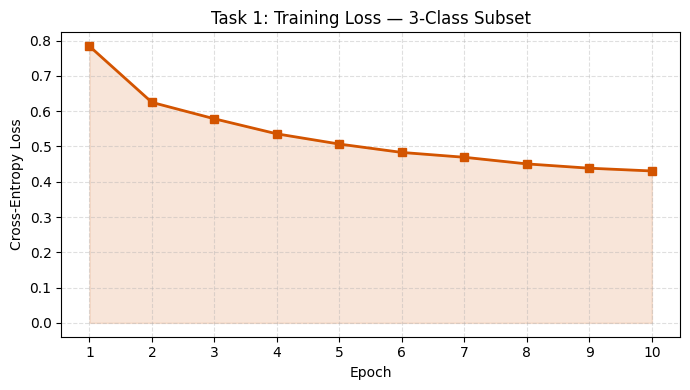

In [10]:
# Loss curve
draw_loss_graph(t1_losses, "Task 1: Training Loss — 3-Class Subset")

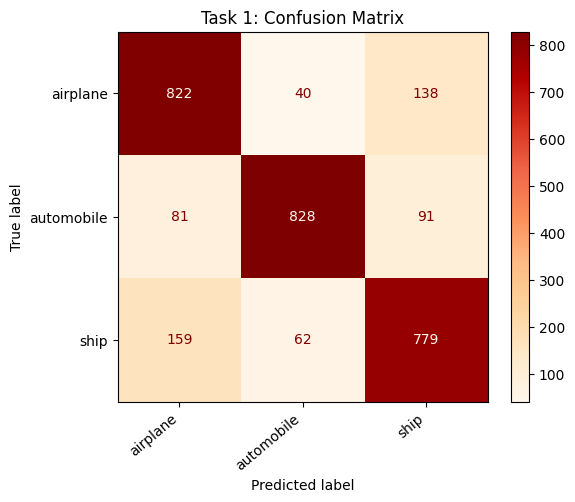

In [11]:
# Confusion matrix
t1_gt, t1_pred = collect_predictions(task1_model, test_loader_t1)
draw_confusion(t1_gt, t1_pred, subset_labels, "Task 1: Confusion Matrix")

---
## Task 2: Full 10-Class Classification

We reuse the same single-conv-layer architecture but change the output to 10 classes and train on the entire CIFAR-10 dataset.

In [12]:
class TenClassNet(nn.Module):
    """Same architecture as Task 1, extended to 10 outputs."""

    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
        )
        self.output_layer = nn.Linear(16 * 16 * 16, 10)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.flatten(start_dim=1)
        return self.output_layer(x)

task2_model = TenClassNet()
print(task2_model)
print(f"\nParameter count: {sum(p.numel() for p in task2_model.parameters()):,}")

TenClassNet(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (output_layer): Linear(in_features=4096, out_features=10, bias=True)
)

Parameter count: 41,418


In [13]:
# Full dataset loaders
train_loader_full = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader_full = DataLoader(testing_data, batch_size=64, shuffle=False)

print("Training 10-class CNN...")
t2_losses = train_for_epochs(task2_model, train_loader_full, n_epochs=10)

Training 10-class CNN...
    Epoch  1/10  |  Loss = 1.6328
    Epoch  2/10  |  Loss = 1.3295
    Epoch  3/10  |  Loss = 1.2288
    Epoch  4/10  |  Loss = 1.1769
    Epoch  5/10  |  Loss = 1.1318
    Epoch  6/10  |  Loss = 1.1002
    Epoch  7/10  |  Loss = 1.0656
    Epoch  8/10  |  Loss = 1.0460
    Epoch  9/10  |  Loss = 1.0199
    Epoch 10/10  |  Loss = 1.0035


In [14]:
t2_acc = measure_accuracy(task2_model, test_loader_full)
print(f"\nTask 2 Test Accuracy: {t2_acc}%")


Task 2 Test Accuracy: 60.43%


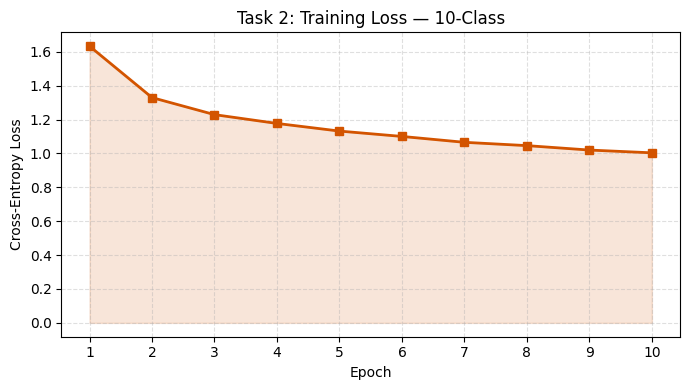

In [15]:
draw_loss_graph(t2_losses, "Task 2: Training Loss — 10-Class")

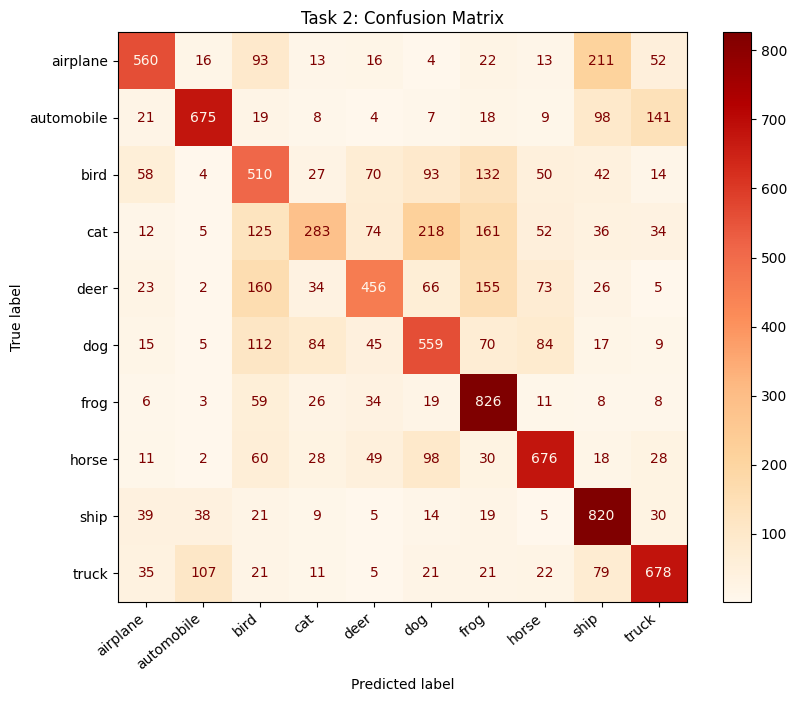

In [16]:
t2_gt, t2_pred = collect_predictions(task2_model, test_loader_full)
draw_confusion(t2_gt, t2_pred, ALL_CATEGORIES, "Task 2: Confusion Matrix")

**Observation:** Accuracy decreases significantly compared to Task 1. The single-layer CNN lacks the depth and representational capacity needed to discriminate between 10 diverse visual categories. Visually similar classes like cat/dog and automobile/truck are frequently confused, as shown in the confusion matrix.

---
## Task 3: Batch Normalization

We add a second convolutional layer (32 filters) and insert batch normalization after each convolution to stabilize training.

**Updated Architecture:**
- Conv2d(3→16, 3×3, same) → BatchNorm2d(16) → ReLU → MaxPool(2,2)
- Conv2d(16→32, 3×3, same) → BatchNorm2d(32) → ReLU
- Flatten → FC(10)

In [17]:
class BNormNet(nn.Module):
    """CNN with batch normalization layers after each convolution."""

    def __init__(self):
        super().__init__()
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # -> 16 x 16 x 16
        )
        self.stage2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),                    # -> 32 x 16 x 16  (no pooling here)
        )
        self.output_layer = nn.Linear(32 * 16 * 16, 10)

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = x.flatten(start_dim=1)
        return self.output_layer(x)

task3_model = BNormNet()
print(task3_model)
print(f"\nParameter count: {sum(p.numel() for p in task3_model.parameters()):,}")

BNormNet(
  (stage1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (stage2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (output_layer): Linear(in_features=8192, out_features=10, bias=True)
)

Parameter count: 87,114


In [18]:
print("Training with BatchNorm...")
t3_losses = train_for_epochs(task3_model, train_loader_full, n_epochs=10)

Training with BatchNorm...
    Epoch  1/10  |  Loss = 1.2960
    Epoch  2/10  |  Loss = 0.9507
    Epoch  3/10  |  Loss = 0.8364
    Epoch  4/10  |  Loss = 0.7550
    Epoch  5/10  |  Loss = 0.6939
    Epoch  6/10  |  Loss = 0.6353
    Epoch  7/10  |  Loss = 0.5939
    Epoch  8/10  |  Loss = 0.5491
    Epoch  9/10  |  Loss = 0.5082
    Epoch 10/10  |  Loss = 0.4671


In [19]:
t3_acc = measure_accuracy(task3_model, test_loader_full)
print(f"\nTask 3 Test Accuracy: {t3_acc}%")


Task 3 Test Accuracy: 64.37%


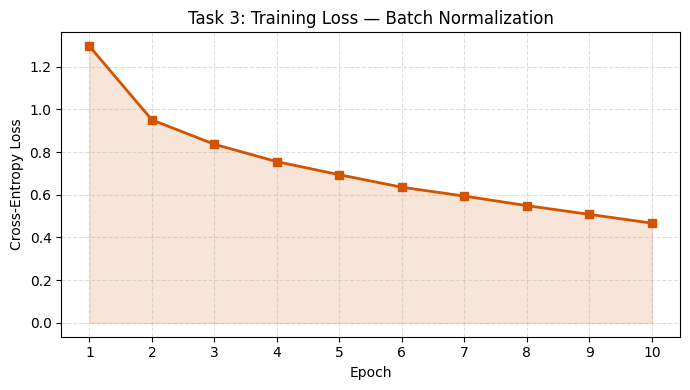

In [20]:
draw_loss_graph(t3_losses, "Task 3: Training Loss — Batch Normalization")

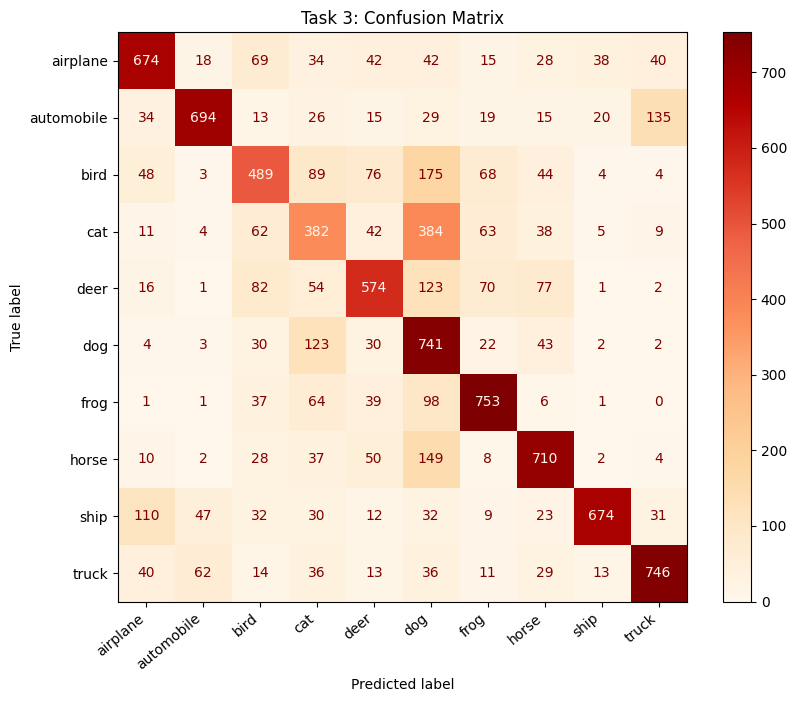

In [21]:
t3_gt, t3_pred = collect_predictions(task3_model, test_loader_full)
draw_confusion(t3_gt, t3_pred, ALL_CATEGORIES, "Task 3: Confusion Matrix")

**Effect of Batch Normalization:**

Batch normalization normalizes the feature maps after each convolution, which keeps the distribution of intermediate activations stable throughout training. This has several benefits: the loss converges faster and more smoothly in the early epochs, the network is less sensitive to the choice of learning rate, and the additional convolutional layer gives the model more capacity to learn complex patterns. As a result, test accuracy improves over the baseline Task 2 architecture.

---
## Task 4: Dropout Regularization + Uncertainty Estimation

We add a Dropout layer (p=0.5) before the fully connected layer. After training, we use Monte Carlo Dropout to estimate prediction uncertainty on the first test sample.

**Updated Architecture:**
- Conv2d(3→16) → BN → ReLU → MaxPool
- Conv2d(16→32) → BN → ReLU
- Dropout(0.5)
- Flatten → FC(10)

In [22]:
class DropoutNet(nn.Module):
    """CNN with BatchNorm + Dropout before the classifier head."""

    def __init__(self):
        super().__init__()
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.stage2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )
        self.regularizer = nn.Dropout(p=0.5)
        self.output_layer = nn.Linear(32 * 16 * 16, 10)

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = x.flatten(start_dim=1)
        x = self.regularizer(x)
        return self.output_layer(x)

task4_model = DropoutNet()
print(task4_model)
print(f"\nParameter count: {sum(p.numel() for p in task4_model.parameters()):,}")

DropoutNet(
  (stage1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (stage2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (regularizer): Dropout(p=0.5, inplace=False)
  (output_layer): Linear(in_features=8192, out_features=10, bias=True)
)

Parameter count: 87,114


In [23]:
print("Training with Dropout...")
t4_losses = train_for_epochs(task4_model, train_loader_full, n_epochs=10)

Training with Dropout...
    Epoch  1/10  |  Loss = 1.4530
    Epoch  2/10  |  Loss = 1.1207
    Epoch  3/10  |  Loss = 1.0107
    Epoch  4/10  |  Loss = 0.9574
    Epoch  5/10  |  Loss = 0.9158
    Epoch  6/10  |  Loss = 0.8830
    Epoch  7/10  |  Loss = 0.8648
    Epoch  8/10  |  Loss = 0.8351
    Epoch  9/10  |  Loss = 0.8198
    Epoch 10/10  |  Loss = 0.8057


In [24]:
t4_acc = measure_accuracy(task4_model, test_loader_full)
print(f"\nTask 4 Test Accuracy: {t4_acc}%")


Task 4 Test Accuracy: 68.29%


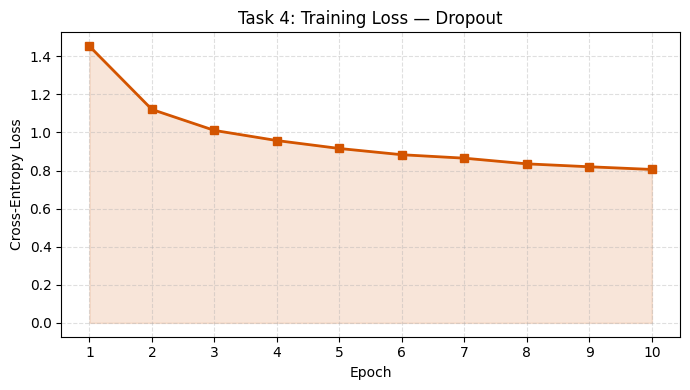

In [25]:
draw_loss_graph(t4_losses, "Task 4: Training Loss — Dropout")

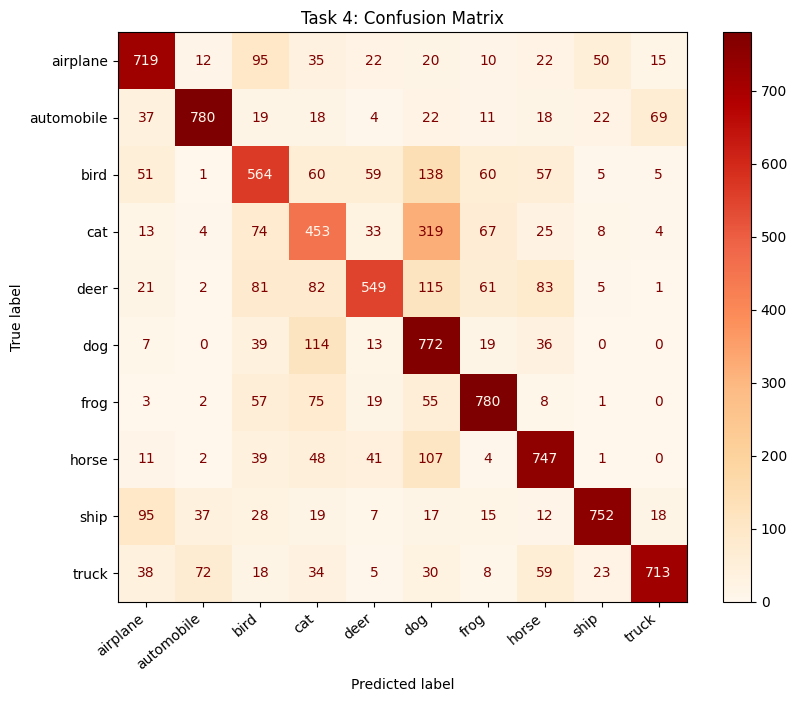

In [26]:
t4_gt, t4_pred = collect_predictions(task4_model, test_loader_full)
draw_confusion(t4_gt, t4_pred, ALL_CATEGORIES, "Task 4: Confusion Matrix")

### Monte Carlo Dropout — Uncertainty Estimation

We run 100 stochastic forward passes through the network (keeping dropout active) on the first test image, recording the softmax probabilities each time. The mean probability per class shows the model's average confidence, while the standard deviation reveals uncertainty.

In [27]:
# Find the first airplane image in the test set (class index 0)
sample_idx = next(i for i in range(len(testing_data)) if testing_data[i][1] == 0)
sample_image, sample_label = testing_data[sample_idx]
sample_batch = sample_image.unsqueeze(0).to(compute_device)
print(f"Using test sample index {sample_idx} (class: {ALL_CATEGORIES[sample_label]})")

# Activate dropout during inference
task4_model.train()

stochastic_outputs = []
with torch.no_grad():
    for run in range(100):
        raw_logits = task4_model(sample_batch)
        softmax_probs = F.softmax(raw_logits, dim=1).cpu().numpy().ravel()
        stochastic_outputs.append(softmax_probs)

stochastic_outputs = np.array(stochastic_outputs)  # shape: (100, 10)
mean_probability = stochastic_outputs.mean(axis=0)
std_probability = stochastic_outputs.std(axis=0)

print(f"True label: {ALL_CATEGORIES[sample_label]}")
print(f"Mean predicted class: {ALL_CATEGORIES[mean_probability.argmax()]}")
print(f"Mean confidence: {mean_probability.max():.3f} ± {std_probability[mean_probability.argmax()]:.3f}")

Using test sample index 3 (class: airplane)
True label: airplane
Mean predicted class: bird
Mean confidence: 0.376 ± 0.200


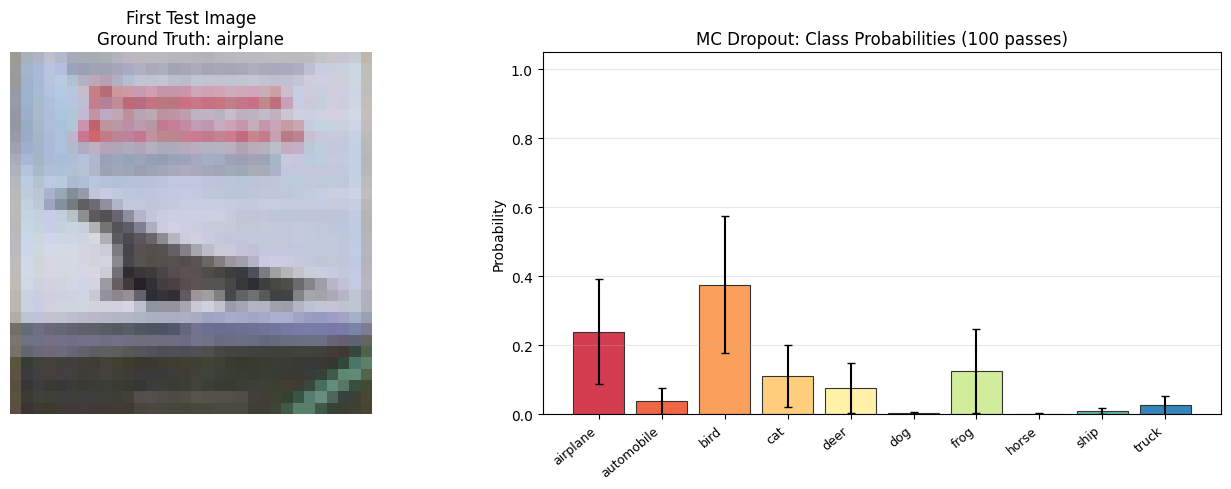

In [28]:
# Bar chart: average class probabilities with uncertainty bands
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: the test image
img_for_display = sample_image.permute(1, 2, 0).numpy()
axes[0].imshow(img_for_display)
axes[0].set_title(f"First Test Image\nGround Truth: {ALL_CATEGORIES[sample_label]}", fontsize=12)
axes[0].axis('off')

# Right: MC Dropout probability bar chart
bar_positions = np.arange(10)
palette = plt.cm.Spectral(np.linspace(0.1, 0.9, 10))
axes[1].bar(bar_positions, mean_probability, yerr=std_probability,
            color=palette, edgecolor='#333', capsize=3, linewidth=0.8)
axes[1].set_xticks(bar_positions)
axes[1].set_xticklabels(ALL_CATEGORIES, rotation=40, ha='right', fontsize=9)
axes[1].set_ylabel("Probability")
axes[1].set_title("MC Dropout: Class Probabilities (100 passes)", fontsize=12)
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Effect of Dropout:**

Dropout forces the network to develop redundant feature representations since any neuron might be deactivated during a given forward pass. This reduces overfitting and typically leads to better generalization on unseen data. The MC Dropout analysis provides a practical measure of prediction uncertainty — when the model is confident, the bar chart shows a single dominant class with low variance; when uncertain, probability mass spreads across multiple classes with higher standard deviations.

---
## Task 5: Improved Architecture

We design a deeper CNN with the following enhancements:
- **Three convolutional blocks** with increasing filter counts (32 → 64 → 128)
- **Two convolutions per block** for richer feature extraction
- **BatchNorm + Dropout2D** in every block
- **Global Average Pooling** instead of flattening (reduces parameters)
- **Hidden FC layer** (128 → 64) before the classifier
- **Data augmentation** (random flips and crops)
- **Learning rate scheduling** (reduce LR after epoch 8)
- **Weight decay** for L2 regularization
- **15 training epochs** with batch size 128

In [29]:
class ImprovedNet(nn.Module):
    """
    Deeper CNN with 3 conv blocks, global avg pooling,
    and a hidden fully-connected layer.
    """

    def __init__(self):
        super().__init__()

        # Block A: 3 -> 32 channels
        self.block_a = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),
        )

        # Block B: 32 -> 64 channels
        self.block_b = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
        )

        # Block C: 64 -> 128 channels + global average pooling
        self.block_c = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),  # -> 128 x 1 x 1
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.block_a(x)
        x = self.block_b(x)
        x = self.block_c(x)
        x = x.flatten(start_dim=1)
        return self.classifier(x)

task5_model = ImprovedNet()
print(task5_model)
total_p = sum(p.numel() for p in task5_model.parameters())
print(f"\nParameter count: {total_p:,}")

ImprovedNet(
  (block_a): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
  )
  (block_b): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=

In [30]:
# Augmented data loader for Task 5
augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])

augmented_train = torchvision.datasets.CIFAR10(
    root='./cifar10_files', train=True, download=False, transform=augmented_transform
)

train_loader_t5 = DataLoader(augmented_train, batch_size=128, shuffle=True)

print("Task 5 Training Configuration:")
print("  Batch size:      128")
print("  Epochs:          15")
print("  Optimizer:       Adam (lr=0.001, weight_decay=1e-4)")
print("  LR Schedule:     StepLR (step=8, gamma=0.5)")
print("  Augmentation:    RandomHorizontalFlip + RandomCrop(32, pad=4)")
print("  Loss:            CrossEntropyLoss")

Task 5 Training Configuration:
  Batch size:      128
  Epochs:          15
  Optimizer:       Adam (lr=0.001, weight_decay=1e-4)
  LR Schedule:     StepLR (step=8, gamma=0.5)
  Augmentation:    RandomHorizontalFlip + RandomCrop(32, pad=4)
  Loss:            CrossEntropyLoss


In [31]:
# Custom training loop with LR scheduling
task5_model.to(compute_device)

criterion_t5 = nn.CrossEntropyLoss()
optimizer_t5 = optim.Adam(task5_model.parameters(), lr=0.001, weight_decay=1e-4)
lr_schedule = optim.lr_scheduler.StepLR(optimizer_t5, step_size=8, gamma=0.5)

t5_losses = []
NUM_EPOCHS = 15

for ep in range(1, NUM_EPOCHS + 1):
    task5_model.train()
    running = 0.0
    steps = 0

    for imgs, labels in train_loader_t5:
        imgs, labels = imgs.to(compute_device), labels.to(compute_device)
        optimizer_t5.zero_grad()
        out = task5_model(imgs)
        loss = criterion_t5(out, labels)
        loss.backward()
        optimizer_t5.step()
        running += loss.item()
        steps += 1

    lr_schedule.step()
    avg = running / steps
    t5_losses.append(avg)
    current_lr = optimizer_t5.param_groups[0]['lr']
    print(f"    Epoch {ep:>2d}/{NUM_EPOCHS}  |  Loss = {avg:.4f}  |  LR = {current_lr:.6f}")

    Epoch  1/15  |  Loss = 1.7908  |  LR = 0.001000
    Epoch  2/15  |  Loss = 1.5285  |  LR = 0.001000
    Epoch  3/15  |  Loss = 1.3842  |  LR = 0.001000
    Epoch  4/15  |  Loss = 1.2763  |  LR = 0.001000
    Epoch  5/15  |  Loss = 1.1880  |  LR = 0.001000
    Epoch  6/15  |  Loss = 1.1191  |  LR = 0.001000
    Epoch  7/15  |  Loss = 1.0670  |  LR = 0.001000
    Epoch  8/15  |  Loss = 1.0196  |  LR = 0.000500
    Epoch  9/15  |  Loss = 0.9451  |  LR = 0.000500
    Epoch 10/15  |  Loss = 0.9118  |  LR = 0.000500
    Epoch 11/15  |  Loss = 0.9023  |  LR = 0.000500
    Epoch 12/15  |  Loss = 0.8803  |  LR = 0.000500
    Epoch 13/15  |  Loss = 0.8607  |  LR = 0.000500
    Epoch 14/15  |  Loss = 0.8543  |  LR = 0.000500
    Epoch 15/15  |  Loss = 0.8319  |  LR = 0.000500


In [32]:
t5_acc = measure_accuracy(task5_model, test_loader_full)
print(f"\nTask 5 Test Accuracy: {t5_acc}%")


Task 5 Test Accuracy: 77.38%


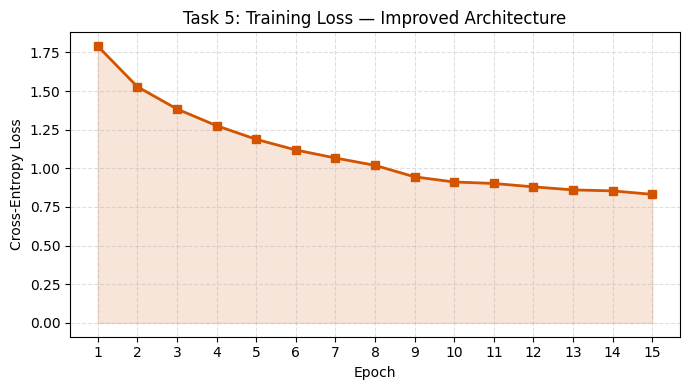

In [33]:
draw_loss_graph(t5_losses, "Task 5: Training Loss — Improved Architecture")

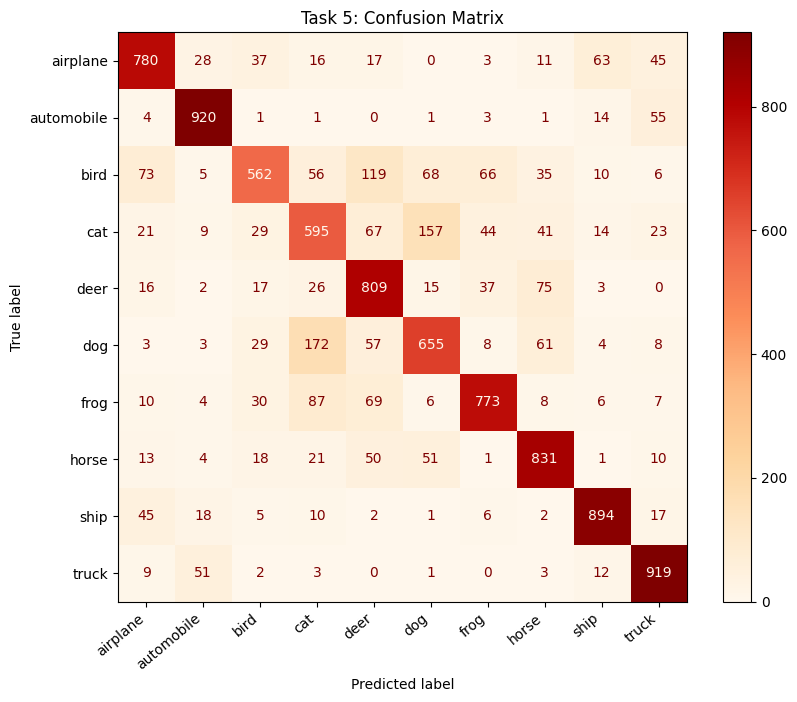

In [34]:
t5_gt, t5_pred = collect_predictions(task5_model, test_loader_full)
draw_confusion(t5_gt, t5_pred, ALL_CATEGORIES, "Task 5: Confusion Matrix")

### Task 5: MC Dropout — First Test Sample

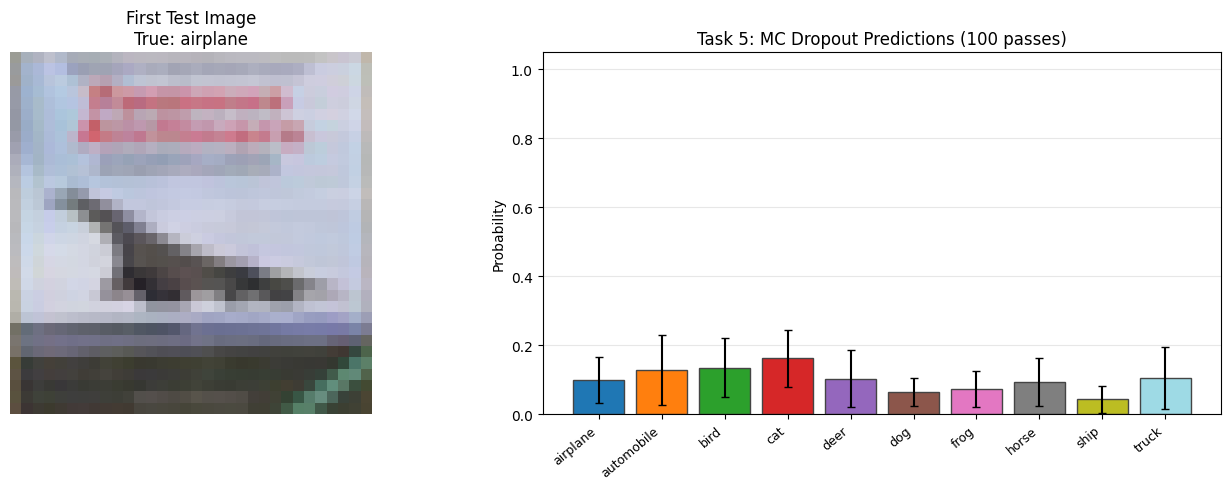

In [35]:
# MC Dropout on first airplane in the test set
t5_idx = next(i for i in range(len(testing_data)) if testing_data[i][1] == 0)
t5_sample, t5_label = testing_data[t5_idx]
t5_input = t5_sample.unsqueeze(0).to(compute_device)

task5_model.train()  # keep dropout active
mc_runs = []
with torch.no_grad():
    for _ in range(100):
        logits = task5_model(t5_input)
        probs = F.softmax(logits, dim=1).cpu().numpy().ravel()
        mc_runs.append(probs)

mc_runs = np.array(mc_runs)
mc_mean = mc_runs.mean(axis=0)
mc_std = mc_runs.std(axis=0)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(t5_sample.permute(1, 2, 0).numpy())
axes[0].set_title(f"First Test Image\nTrue: {ALL_CATEGORIES[t5_label]}", fontsize=12)
axes[0].axis('off')

colors_t5 = plt.cm.tab20(np.linspace(0, 0.95, 10))
axes[1].bar(range(10), mc_mean, yerr=mc_std, color=colors_t5,
            edgecolor='#444', capsize=3)
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(ALL_CATEGORIES, rotation=40, ha='right', fontsize=9)
axes[1].set_ylabel("Probability")
axes[1].set_title("Task 5: MC Dropout Predictions (100 passes)", fontsize=12)
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Results Summary

In [36]:
print("=" * 55)
print("  TASK   |  ARCHITECTURE          |  TEST ACCURACY")
print("-" * 55)
print(f"  1      |  Basic CNN (3-class)   |  {t1_acc}%")
print(f"  2      |  Basic CNN (10-class)  |  {t2_acc}%")
print(f"  3      |  + Batch Normalization |  {t3_acc}%")
print(f"  4      |  + Dropout (p=0.5)     |  {t4_acc}%")
print(f"  5      |  Deep CNN + Augment    |  {t5_acc}%")
print("=" * 55)

  TASK   |  ARCHITECTURE          |  TEST ACCURACY
-------------------------------------------------------
  1      |  Basic CNN (3-class)   |  80.97%
  2      |  Basic CNN (10-class)  |  60.43%
  3      |  + Batch Normalization |  64.37%
  4      |  + Dropout (p=0.5)     |  68.29%
  5      |  Deep CNN + Augment    |  77.38%
